In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# silence warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('data.tsv', delimiter='\t')

In [3]:
headers = ['URL', 'Name', 'Price', 'Manufacturer', 'Age Group', 'Hand', 'Flex', 'Stick Length', 'Blade Curve', 'Brand', 'Family', 'Composite Stick Brand']

df.columns = headers


In [4]:
df

,URL,Name,Price,Manufacturer,Age Group,Hand,Flex,Stick Length,Blade Curve,Brand,Family,Composite Stick Brand
0,https://eishockey-onlineshop.de/Stick-CCM-JETS...,Stick CCM JETSPEED FT7 PRO Senior 70 Flex 60-Inch,"259,95 €",CCM,Senior,Unknown,70,60 Inch,"P28, P29",CCM,Jetspeed,CCM
1,https://eishockey-onlineshop.de/Stick-Bauer-Tw...,Stick Bauer Twitch 50-Inch 30 Flex Junior,"219,95 €",Bauer,Junior,left,30,50 Inch,P92,Bauer,Twitch,Bauer
2,https://eishockey-onlineshop.de/Stick-Bauer-Tw...,Stick Bauer Twitch 52-Inch 40 Flex Junior,"219,95 €",Bauer,Junior,left,40,52 Inch,P92,Bauer,Twitch,Bauer
3,https://eishockey-onlineshop.de/Stick-Bauer-Tw...,Stick Bauer Twitch 54-Inch 50 Flex Junior,"229,95 €",Bauer,Junior,left,50,54 Inch,P92,Bauer,Twitch,Bauer
4,https://eishockey-onlineshop.de/Stick-Bauer-Tw...,Stick Bauer Twitch 58-Inch 55 Flex Intermediate,"279,95 €",Bauer,Intermediate,left,55,58 Inch,P92,Bauer,Twitch,Bauer
...,...,...,...,...,...,...,...,...,...,...,...,...
573,https://eishockey-onlineshop.de/Stick-True-XC7...,Stick True XC7 ACF Senior 75 Flex,"89,95 €",True,Senior,Unknown,75,Unknown,Unknown,True,Unknown,True
574,https://eishockey-onlineshop.de/Stick-Composit...,Stick Composite Vanx Argon Pro X3000 Intermediate,"99,95 €",Vanx,Intermediate,right,"55, 70",Unknown,V92,Vanx,Unknown,Unknown
575,https://eishockey-onlineshop.de/Stick-Composit...,Stick Composite Vanx Xenon Pro G1 Intermediate,"99,95 €",Vanx,Intermediate,right,55,Unknown,V92,Vanx,Unknown,Unknown
576,https://eishockey-onlineshop.de/Schlaeger-Comp...,Schläger Composite Warrior COVERT QRE3 Interme...,"119,95 €",Warrior,Intermediate,"left, right","55, 70",Unknown,"W03, W28, W88",Warrior,Covert,Warrior


In [5]:

for column in df.columns:
    if column == 'URL' or column == 'Name':
        continue
    print(f"Column: {column}")
    print(f"Unique values: {df[column].nunique()}")
    print(f"Most frequent values:\n{df[column].value_counts().head()}")
    print(f"Range of values: {df[column].min()} - {df[column].max()}")
    try :
        print(f"Mean: {df[column].mean()}")
        print(f"Standard Deviation: {df[column].std()}")
    except:
        pass

    print("\n")

Column: Price
Unique values: 87
Most frequent values:
Price
199,95 €    35
109,95 €    28
139,95 €    27
169,95 €    26
189,00 €    20
Name: count, dtype: int64
Range of values: 104,95 € - 99,95 €


Column: Manufacturer
Unique values: 8
Most frequent values:
Manufacturer
Warrior     196
CCM         115
Bauer       110
Sherwood     67
True         67
Name: count, dtype: int64
Range of values: Bauer - Warrior


Column: Age Group
Unique values: 5
Most frequent values:
Age Group
Senior          250
Intermediate    147
Junior          138
Youth            40
Unknown           3
Name: count, dtype: int64
Range of values: Intermediate - Youth


Column: Hand
Unique values: 4
Most frequent values:
Hand
left, right    339
right           96
Unknown         90
left            53
Name: count, dtype: int64
Range of values: Unknown - right


Column: Flex
Unique values: 27
Most frequent values:
Flex
85    66
75    63
50    62
65    62
55    59
Name: count, dtype: int64
Range of values: 10 - Unknown



In [6]:
df_graph = df.__deepcopy__()

In [7]:
df_attrib = df.__deepcopy__()

df_attrib.replace('Unknown', np.nan, inplace=True)
df_attrib['Hand'] = df_attrib['Hand'].str.split(', ')
df_attrib = df_attrib.explode('Hand')

df_attrib['Price'] = df_attrib['Price'].str.replace(' €', '').str.replace(',','.').astype(float)

df_attrib['Flex'] = df_attrib['Flex'].str.split(', ')
df_attrib = df_attrib.explode('Flex')
df_attrib['Flex'] = df_attrib['Flex'].astype(float)

df_attrib['Stick Length'] = df_attrib['Stick Length'].str.replace(' Inch', '').astype(float)

df_attrib['Blade Curve'] = df_attrib['Blade Curve'].str.split(', ')
df_attrib = df_attrib.explode('Blade Curve')

for column in df_attrib.columns:
    print(f"Column: {column}")
    print(f"Unique values: {df_attrib[column].nunique()}")
    print(f"Most frequent values:\n{df_attrib[column].value_counts().head()}")
    try :
        print(f"Range of values: {df_attrib[column].min()} - {df_attrib[column].max()}")
    except:
        pass

    try :
        print(f"Mean: {df_attrib[column].mean()}")
    except:
        pass

    try :
        print(f"Standard Deviation: {df_attrib[column].std()}")
    except:
        pass

    print("\n")

Column: URL
Unique values: 578
Most frequent values:
URL
https://eishockey-onlineshop.de/Schlaeger-Composite-Warrior-COVERT-QRE3-Junior_1          18
https://eishockey-onlineshop.de/Schlaeger-Composite-Warrior-COVERT-QRE3-Intermediate_1    12
https://eishockey-onlineshop.de/Stick-Bauer-Vapor-HYP2RLITE-Senior-62-Inch-77-Flex        10
https://eishockey-onlineshop.de/Stick-True-Catalyst-7X3-Senior-65-Flex-60-Inch            10
https://eishockey-onlineshop.de/Stick-True-Catalyst-9X3-Senior-85-Flex-62-Inch            10
Name: count, dtype: int64
Range of values: https://eishockey-onlineshop.de/Schlaeger-Composite-Warrior-COVERT-QRE3-Intermediate_1 - https://eishockey-onlineshop.de/Stick-Warrior-Super-Novium-85-Flex-63-Inch-Senior


Column: Name
Unique values: 578
Most frequent values:
Name
Schläger Composite Warrior COVERT QRE3 Junior          18
Schläger Composite Warrior COVERT QRE3 Intermediate    12
Stick Bauer Vapor HYP2RLITE Senior 62-Inch 77 Flex     10
Stick True Catalyst 7X3 Senio

<Axes: xlabel='Hand', ylabel='Count'>

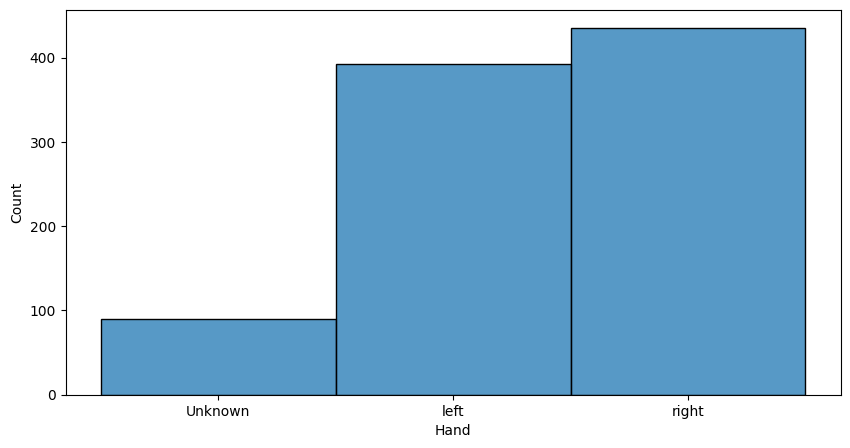

In [8]:
df_graph['Hand'] = df_graph['Hand'].str.split(', ')
df_graph = df_graph.explode('Hand')

ax, fig = plt.subplots(figsize=(10, 5))
sns.histplot(df_graph['Hand'])

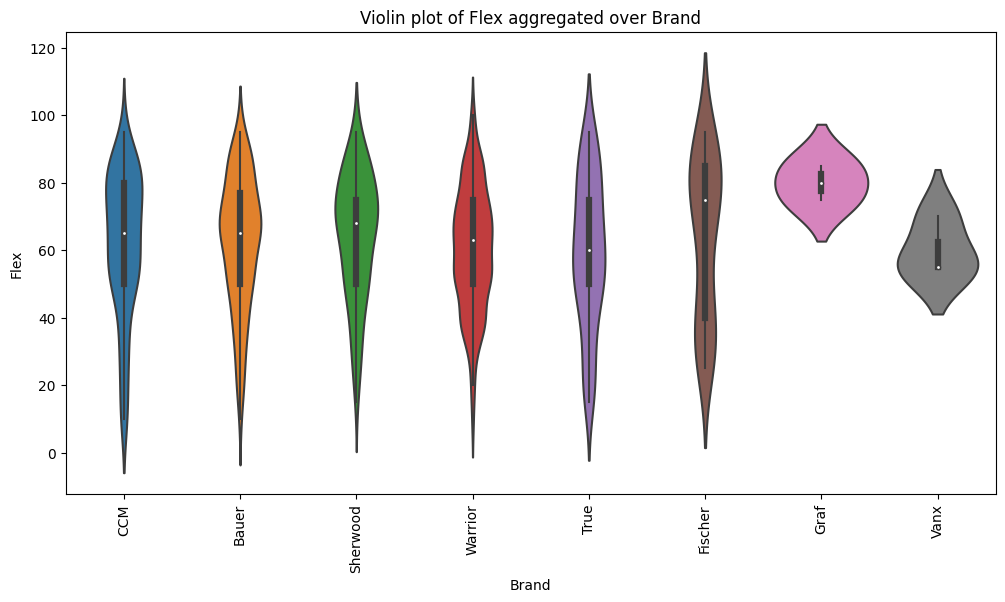

In [9]:
df_graph['Flex'] = df_graph['Flex'].str.split(', ')
df_graph = df_graph.explode('Flex')
df_graph = df_graph[df_graph['Flex'] != 'Unknown']
df_graph['Flex'] = df_graph['Flex'].astype(int)

plt.figure(figsize=(12, 6))
sns.violinplot(x='Brand', y='Flex', data=df_graph)
plt.xticks(rotation=90)
plt.title('Violin plot of Flex aggregated over Brand')
plt.show()

In [10]:
df_graph['Price_adj'] = df_graph['Price'].str.replace(' €', '').str.replace(',','.').astype(float)

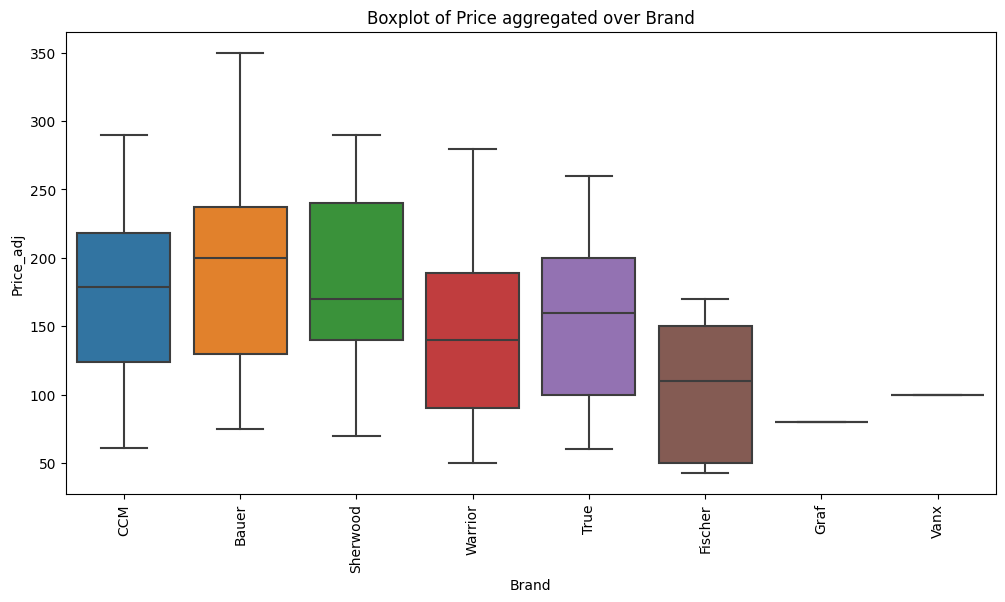

In [11]:

plt.figure(figsize=(12, 6))
sns.boxplot(x='Brand', y='Price_adj', data=df_graph)
plt.xticks(rotation=90)
plt.title('Boxplot of Price aggregated over Brand')
plt.show()

In [12]:

bins = np.linspace(df_graph['Flex'].min(), df_graph['Flex'].max(), 20)
df_graph['Flex_binned'] = pd.cut(df_graph['Flex'], bins)

# Calculate the ECDF for each bin
ecdf = df_graph['Flex_binned'].value_counts().sort_index().cumsum() / len(df_graph)

ecdf = pd.DataFrame(ecdf)
bins_mids = pd.DataFrame(ecdf.index.categories.mid)

ecdf_values = np.ndarray.flatten(ecdf.values)
bins_mids = np.ndarray.flatten(bins_mids.values)


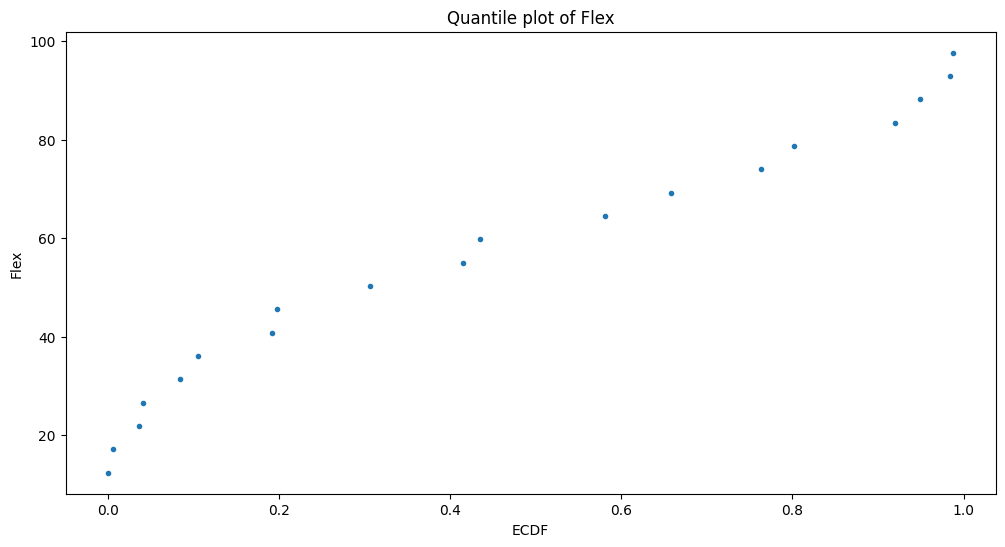

In [13]:

plt.figure(figsize=(12, 6))
plt.plot(ecdf_values, bins_mids, marker='.', linestyle='none')
plt.title('Quantile plot of Flex')
plt.ylabel('Flex')
plt.xlabel('ECDF')
plt.show()


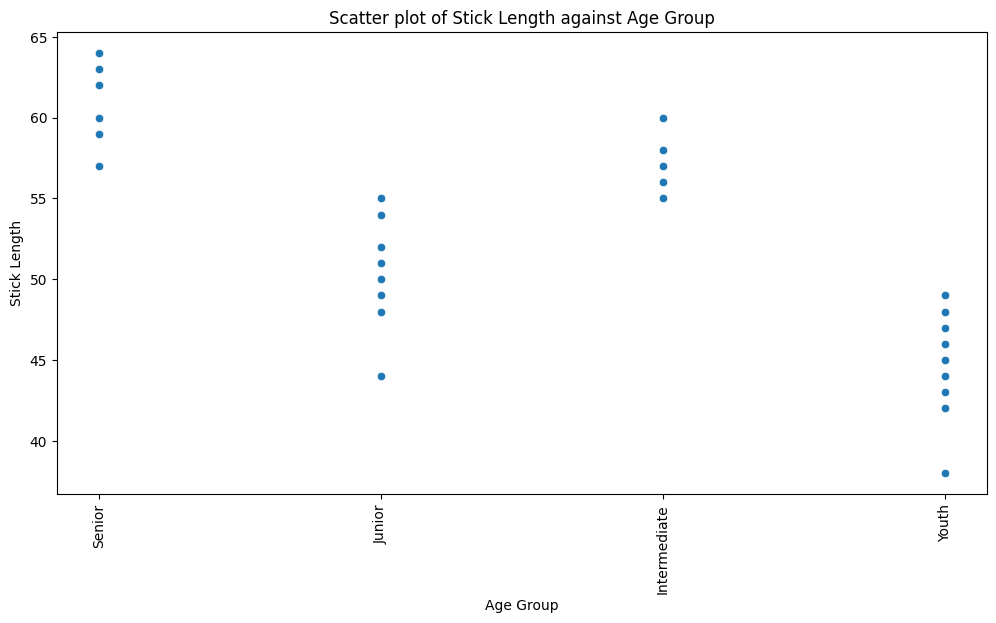

In [14]:
df_graph['Stick Length'] = df_graph['Stick Length'].str.replace(' Inch', '')

# remove the rows with 'Unknown' values
df_graph = df_graph[df_graph['Stick Length'] != 'Unknown']
df_graph['Stick Length'] = df_graph['Stick Length'].astype(int)

plt.figure(figsize=(12, 6))
sns.scatterplot(x='Age Group', y='Stick Length', data=df_graph)
plt.xticks(rotation=90)
plt.title('Scatter plot of Stick Length against Age Group')
plt.show()


# Odlahle hodnoty

In [15]:
def IQR_outliers(column):
    q1 = column.quantile(0.25)
    q3 = column.quantile(0.75)
    iqr = q3 - q1
    print(f"Lower bound: {q1 - 1.5 * iqr}")
    print(f"Upper bound: {q3 + 1.5 * iqr}")

    return column[(column < (q1 - 1.5 * iqr)) | (column > (q3 + 1.5 * iqr))]

In [16]:
outliers_length = IQR_outliers(df_graph['Stick Length'])
outliers_length = outliers_length.groupby(outliers_length).count()
outliers_length = pd.DataFrame(outliers_length)
outliers_length = outliers_length.drop(columns='Stick Length')
outliers_length

Lower bound: 45.0
Upper bound: 69.0


""
Stick Length
38
42
43
44


In [17]:
outliers_price = IQR_outliers(df_graph['Price_adj'])
outliers_price = outliers_price.groupby(outliers_price).count()
outliers_price = pd.DataFrame(outliers_price)
outliers_price = outliers_price.drop(columns='Price_adj')
outliers_price

Lower bound: -53.624999999999986
Upper bound: 382.575


""
Price_adj


In [18]:
outliers_flex = IQR_outliers(df_graph['Flex'])
outliers_flex = outliers_flex.groupby(outliers_flex).count()
outliers_flex = pd.DataFrame(outliers_flex)
outliers_flex = outliers_flex.drop(columns='Flex')
outliers_flex

Lower bound: 12.5
Upper bound: 112.5


""
Flex
10


In [19]:
df.replace('Unknown', np.nan, inplace=True)

missing_values_count = df.isnull().sum()
total_missing = missing_values_count.sum()
rows_with_missing_values = df.isnull().sum(axis=1)
rows_with_multiple_missing = rows_with_missing_values[rows_with_missing_values > 1].count()

print("Total number of missing values in each column:")
missing_values = pd.DataFrame(missing_values_count)
missing_values.columns = ['Missing Values']
display(missing_values)
print("\nTotal number of missing values in the whole dataframe:")
print(total_missing)
print("\nNumber of rows with multiple missing values:")
print(rows_with_multiple_missing)

Total number of missing values in each column:


,Missing Values
URL,0
Name,0
Price,0
Manufacturer,0
Age Group,3
Hand,90
Flex,6
Stick Length,70
Blade Curve,18
Brand,2



Total number of missing values in the whole dataframe:
199

Number of rows with multiple missing values:
21


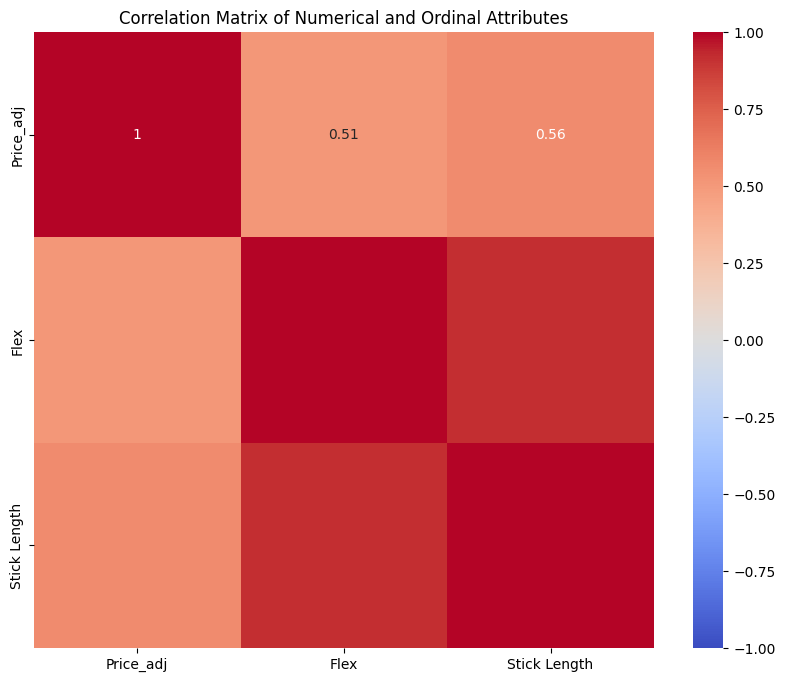

In [55]:
# Select numerical and ordinal columns for correlation analysis
numerical_columns = ['Price_adj', 'Flex', 'Stick Length']

# Calculate the correlation matrix
correlation_matrix = df_graph[numerical_columns].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical and Ordinal Attributes')
plt.show()

# Uloha 2


In [21]:
df = pd.read_csv('data.tsv', delimiter='\t')
headers = ['URL', 'Name', 'Price', 'Manufacturer', 'Age Group', 'Hand', 'Flex', 'Stick Length', 'Blade Curve', 'Brand', 'Family', 'Composite Stick Brand']
df.columns = headers
df.replace('Unknown', np.nan, inplace=True)
df['Price'] = df['Price'].str.replace(' €', '').str.replace(',','.').astype(float)


In [22]:
df.shape

(578, 12)

Odstranenie riadkov, kde Family a Blade Curve je Unknown

In [23]:
df = df[~df['Family'].isnull()]
df = df[~df['Blade Curve'].isnull()]

In [24]:
df.shape

(556, 12)

In [25]:
df

,URL,Name,Price,Manufacturer,Age Group,Hand,Flex,Stick Length,Blade Curve,Brand,Family,Composite Stick Brand
0,https://eishockey-onlineshop.de/Stick-CCM-JETS...,Stick CCM JETSPEED FT7 PRO Senior 70 Flex 60-Inch,259.95,CCM,Senior,NaN,70,60 Inch,"P28, P29",CCM,Jetspeed,CCM
1,https://eishockey-onlineshop.de/Stick-Bauer-Tw...,Stick Bauer Twitch 50-Inch 30 Flex Junior,219.95,Bauer,Junior,left,30,50 Inch,P92,Bauer,Twitch,Bauer
2,https://eishockey-onlineshop.de/Stick-Bauer-Tw...,Stick Bauer Twitch 52-Inch 40 Flex Junior,219.95,Bauer,Junior,left,40,52 Inch,P92,Bauer,Twitch,Bauer
3,https://eishockey-onlineshop.de/Stick-Bauer-Tw...,Stick Bauer Twitch 54-Inch 50 Flex Junior,229.95,Bauer,Junior,left,50,54 Inch,P92,Bauer,Twitch,Bauer
4,https://eishockey-onlineshop.de/Stick-Bauer-Tw...,Stick Bauer Twitch 58-Inch 55 Flex Intermediate,279.95,Bauer,Intermediate,left,55,58 Inch,P92,Bauer,Twitch,Bauer
...,...,...,...,...,...,...,...,...,...,...,...,...
570,https://eishockey-onlineshop.de/Stick-Composit...,Stick Composite Warrior Alpha DX3 40 Flex Junior,69.95,Warrior,Junior,"left, right",40,NaN,"W03, W28",Warrior,Alpha,Warrior
571,https://eishockey-onlineshop.de/Stick-Composit...,Stick Composite Warrior Alpha DX3 50 Flex Junior,69.95,Warrior,Junior,"left, right",50,NaN,"W03, W28",Warrior,Alpha,Warrior
572,https://eishockey-onlineshop.de/Stick-Composit...,Stick Composite Warrior Alpha DX5 50 Flex Junior,55.95,Warrior,Junior,right,50,NaN,W03,Warrior,Alpha,Warrior
576,https://eishockey-onlineshop.de/Schlaeger-Comp...,Schläger Composite Warrior COVERT QRE3 Interme...,119.95,Warrior,Intermediate,"left, right","55, 70",NaN,"W03, W28, W88",Warrior,Covert,Warrior


In [26]:
# remove rows with more than 2 missing values

df = df[df.isnull().sum(axis=1) <= 2]

In [27]:
df.shape

(556, 12)

In [28]:
# where hand is null, the stick is for both hands
df['Hand'].fillna('left, right', inplace=True)

In [29]:
df['Stick Length'] = df['Stick Length'].str.replace(' Inch', '')



In [30]:
# calculate the mean stick length for each age group

df_without_unknown = df[df['Stick Length'].isnull() == False]
df_without_unknown['Stick Length'] = df_without_unknown['Stick Length'].astype(int)
mean_stick_length = df_without_unknown.groupby('Age Group')['Stick Length'].mean()
mean_stick_length

Age Group
Intermediate    57.426230
Junior          51.752137
Senior          61.237668
Youth           45.138889
Name: Stick Length, dtype: float64

In [31]:
# fill the missing stick lengths with the mean stick length of the respective age group
df['Stick Length'] = df.apply(lambda row: mean_stick_length[row['Age Group']] if pd.isnull(row['Stick Length']) else row['Stick Length'], axis=1)
df['Stick Length'] = df['Stick Length'].astype(int)

In [32]:
temp = df[df['Brand'].isnull()]
temp

,URL,Name,Price,Manufacturer,Age Group,Hand,Flex,Stick Length,Blade Curve,Brand,Family,Composite Stick Brand


at this point, there are no missing values, only values that are not atomic, so next step is to explode them into atomic values

In [33]:
df['Flex'] = df['Flex'].str.split(', ')
df = df.explode('Flex')
df['Flex'] = df['Flex'].astype(int)

df['Hand'] = df['Hand'].str.split(', ')
df = df.explode('Hand')

df['Blade Curve'] = df['Blade Curve'].str.split(', ')
df = df.explode('Blade Curve')

In [34]:
df

,URL,Name,Price,Manufacturer,Age Group,Hand,Flex,Stick Length,Blade Curve,Brand,Family,Composite Stick Brand
0,https://eishockey-onlineshop.de/Stick-CCM-JETS...,Stick CCM JETSPEED FT7 PRO Senior 70 Flex 60-Inch,259.95,CCM,Senior,left,70,60,P28,CCM,Jetspeed,CCM
0,https://eishockey-onlineshop.de/Stick-CCM-JETS...,Stick CCM JETSPEED FT7 PRO Senior 70 Flex 60-Inch,259.95,CCM,Senior,left,70,60,P29,CCM,Jetspeed,CCM
0,https://eishockey-onlineshop.de/Stick-CCM-JETS...,Stick CCM JETSPEED FT7 PRO Senior 70 Flex 60-Inch,259.95,CCM,Senior,right,70,60,P28,CCM,Jetspeed,CCM
0,https://eishockey-onlineshop.de/Stick-CCM-JETS...,Stick CCM JETSPEED FT7 PRO Senior 70 Flex 60-Inch,259.95,CCM,Senior,right,70,60,P29,CCM,Jetspeed,CCM
1,https://eishockey-onlineshop.de/Stick-Bauer-Tw...,Stick Bauer Twitch 50-Inch 30 Flex Junior,219.95,Bauer,Junior,left,30,50,P92,Bauer,Twitch,Bauer
...,...,...,...,...,...,...,...,...,...,...,...,...
577,https://eishockey-onlineshop.de/Schlaeger-Comp...,Schläger Composite Warrior COVERT QRE3 Junior,89.95,Warrior,Junior,left,50,51,W28,Warrior,Covert,Warrior
577,https://eishockey-onlineshop.de/Schlaeger-Comp...,Schläger Composite Warrior COVERT QRE3 Junior,89.95,Warrior,Junior,left,50,51,W88,Warrior,Covert,Warrior
577,https://eishockey-onlineshop.de/Schlaeger-Comp...,Schläger Composite Warrior COVERT QRE3 Junior,89.95,Warrior,Junior,right,50,51,W03,Warrior,Covert,Warrior
577,https://eishockey-onlineshop.de/Schlaeger-Comp...,Schläger Composite Warrior COVERT QRE3 Junior,89.95,Warrior,Junior,right,50,51,W28,Warrior,Covert,Warrior


odlahle hodnoty

In [35]:
df.shape

(2073, 12)

In [36]:
outlier_columns = ['Stick Length', 'Price', 'Flex']

# Remove the outliers
for column in outlier_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    df = df[(df[column] >= (q1 - 1.5 * iqr)) & (df[column] <= (q3 + 1.5 * iqr))]



In [37]:
df.shape

(2000, 12)

# Prvá varianta dátovej sady - diskretizácia numerických atribútov

In [38]:
df_first = df.__deepcopy__()

In [39]:
# diskretizuj numericke atributy
df_first['Price'] = pd.qcut(df_first['Price'], q=20, labels=False)


In [40]:
df_first['Flex'] = pd.qcut(df_first['Flex'], q=7, labels=False)

In [41]:
df_first['Stick Length'] = pd.qcut(df_first['Stick Length'], q=5, labels=False)

In [42]:
df

,URL,Name,Price,Manufacturer,Age Group,Hand,Flex,Stick Length,Blade Curve,Brand,Family,Composite Stick Brand
0,https://eishockey-onlineshop.de/Stick-CCM-JETS...,Stick CCM JETSPEED FT7 PRO Senior 70 Flex 60-Inch,259.95,CCM,Senior,left,70,60,P28,CCM,Jetspeed,CCM
0,https://eishockey-onlineshop.de/Stick-CCM-JETS...,Stick CCM JETSPEED FT7 PRO Senior 70 Flex 60-Inch,259.95,CCM,Senior,left,70,60,P29,CCM,Jetspeed,CCM
0,https://eishockey-onlineshop.de/Stick-CCM-JETS...,Stick CCM JETSPEED FT7 PRO Senior 70 Flex 60-Inch,259.95,CCM,Senior,right,70,60,P28,CCM,Jetspeed,CCM
0,https://eishockey-onlineshop.de/Stick-CCM-JETS...,Stick CCM JETSPEED FT7 PRO Senior 70 Flex 60-Inch,259.95,CCM,Senior,right,70,60,P29,CCM,Jetspeed,CCM
1,https://eishockey-onlineshop.de/Stick-Bauer-Tw...,Stick Bauer Twitch 50-Inch 30 Flex Junior,219.95,Bauer,Junior,left,30,50,P92,Bauer,Twitch,Bauer
...,...,...,...,...,...,...,...,...,...,...,...,...
577,https://eishockey-onlineshop.de/Schlaeger-Comp...,Schläger Composite Warrior COVERT QRE3 Junior,89.95,Warrior,Junior,left,50,51,W28,Warrior,Covert,Warrior
577,https://eishockey-onlineshop.de/Schlaeger-Comp...,Schläger Composite Warrior COVERT QRE3 Junior,89.95,Warrior,Junior,left,50,51,W88,Warrior,Covert,Warrior
577,https://eishockey-onlineshop.de/Schlaeger-Comp...,Schläger Composite Warrior COVERT QRE3 Junior,89.95,Warrior,Junior,right,50,51,W03,Warrior,Covert,Warrior
577,https://eishockey-onlineshop.de/Schlaeger-Comp...,Schläger Composite Warrior COVERT QRE3 Junior,89.95,Warrior,Junior,right,50,51,W28,Warrior,Covert,Warrior


In [43]:
# save the preprocessed data
df_first.to_csv('data_preprocessed_first.tsv', sep='\t', index=False)

# Druhá varianta dátovej sady - normalizácia numerických atribútov a transformácia kategorických atribútov na numerické

In [44]:
df_second = df.__deepcopy__()

In [45]:
# normalizuj numericke atributy
attributes = ['Price', 'Flex', 'Stick Length']
for attribute in attributes:
    df_second[attribute] = (df_second[attribute] - df_second[attribute].min()) / (df_second[attribute].max() - df_second[attribute].min())


In [46]:
# transformuj kategoricke atributy
attributes = ['Manufacturer', 'Age Group', 'Hand', 'Blade Curve', 'Brand', 'Family', 'Composite Stick Brand']
for attribute in attributes:
    df_second[attribute] = df_second[attribute].astype('category').cat.codes
    # print the mapping
    print(f"Attribute: {attribute}")
    print(df[attribute].value_counts())
    print(df_second[attribute].value_counts())

Attribute: Manufacturer
Manufacturer
Warrior     709
Bauer       397
CCM         389
True        275
Sherwood    186
Fischer      42
Graf          2
Name: count, dtype: int64
Manufacturer
6    709
0    397
1    389
5    275
4    186
2     42
3      2
Name: count, dtype: int64
Attribute: Age Group
Age Group
Senior          989
Intermediate    582
Junior          419
Youth            10
Name: count, dtype: int64
Age Group
2    989
0    582
1    419
3     10
Name: count, dtype: int64
Attribute: Hand
Hand
right    1025
left      975
Name: count, dtype: int64
Hand
1    1025
0     975
Name: count, dtype: int64
Attribute: Blade Curve
Blade Curve
W28             298
W03             296
P28             273
P29             175
P92             174
P90TM            98
PP92             77
T28              75
T92              74
PP28             66
T27              66
M03              43
W88              36
T92.5            35
P88              29
P92M             28
M28              27
PP90MX       

In [47]:
df_second

,URL,Name,Price,Manufacturer,Age Group,Hand,Flex,Stick Length,Blade Curve,Brand,Family,Composite Stick Brand
0,https://eishockey-onlineshop.de/Stick-CCM-JETS...,Stick CCM JETSPEED FT7 PRO Senior 70 Flex 60-Inch,0.777778,1,2,0,0.571429,0.7500,6,1,6,1
0,https://eishockey-onlineshop.de/Stick-CCM-JETS...,Stick CCM JETSPEED FT7 PRO Senior 70 Flex 60-Inch,0.777778,1,2,0,0.571429,0.7500,8,1,6,1
0,https://eishockey-onlineshop.de/Stick-CCM-JETS...,Stick CCM JETSPEED FT7 PRO Senior 70 Flex 60-Inch,0.777778,1,2,1,0.571429,0.7500,6,1,6,1
0,https://eishockey-onlineshop.de/Stick-CCM-JETS...,Stick CCM JETSPEED FT7 PRO Senior 70 Flex 60-Inch,0.777778,1,2,1,0.571429,0.7500,8,1,6,1
1,https://eishockey-onlineshop.de/Stick-Bauer-Tw...,Stick Bauer Twitch 50-Inch 30 Flex Junior,0.629630,0,1,0,0.000000,0.1250,13,0,17,0
...,...,...,...,...,...,...,...,...,...,...,...,...
577,https://eishockey-onlineshop.de/Schlaeger-Comp...,Schläger Composite Warrior COVERT QRE3 Junior,0.148148,6,1,0,0.285714,0.1875,32,6,4,6
577,https://eishockey-onlineshop.de/Schlaeger-Comp...,Schläger Composite Warrior COVERT QRE3 Junior,0.148148,6,1,0,0.285714,0.1875,33,6,4,6
577,https://eishockey-onlineshop.de/Schlaeger-Comp...,Schläger Composite Warrior COVERT QRE3 Junior,0.148148,6,1,1,0.285714,0.1875,30,6,4,6
577,https://eishockey-onlineshop.de/Schlaeger-Comp...,Schläger Composite Warrior COVERT QRE3 Junior,0.148148,6,1,1,0.285714,0.1875,32,6,4,6


In [48]:
df_second.to_csv('data_preprocessed_second.tsv', sep='\t', index=False)